In [8]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid1_firefox_carbonyl7.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid2_firefox_carbonyl7.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid3_firefox_carbonyl7.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid4_firefox_carbonyl7.csv")

In [10]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-4a_chrome_carbonyl7.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8a_chrome_carbonyl7.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8b_carbonyl_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8c_carbonyl_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8d_chrome_carbonyl7.csv")

In [11]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [12]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid4,87.3,85.8,84.6,83.3,82.7,83.5,83.3
1,odroid3,84.1,82.5,82.0,80.9,80.6,80.2,80.3
2,odroid2,87.6,85.3,85.1,83.8,83.5,83.8,83.7
3,odroid2,87.4,86.2,85.0,84.0,84.1,84.0,83.3
4,odroid1,87.6,85.7,85.6,84.4,84.1,83.6,83.5


In [13]:
len(df)

9000

In [14]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250203_022252"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       48.81 GB / 63.72 GB (76.6%)
Disk Space Avail:   1287.74 GB / 1906.98 GB (67.5%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250203_022252"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid4', 'odroid3', 'odroid2', 'odroid1', 'rpi-4a', 'rpi-8a', 'rpi_8c', 'rpi-8d', 'rpi_8b']
	If 'multiclass' is not the correct problem_type, please manually specify th

In [15]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.656076,0.673,0.643548
1,2000,0.711826,0.707,0.696055
2,3000,0.718361,0.720,0.709985
3,4000,0.734257,0.733,0.719846
4,5000,0.732909,0.732,0.720549
5,6000,0.727061,0.728,0.718809
6,7000,0.699757,0.700,0.696480
7,8000,0.726547,0.726,0.713328


<Axes: xlabel='data_amount', ylabel='value'>

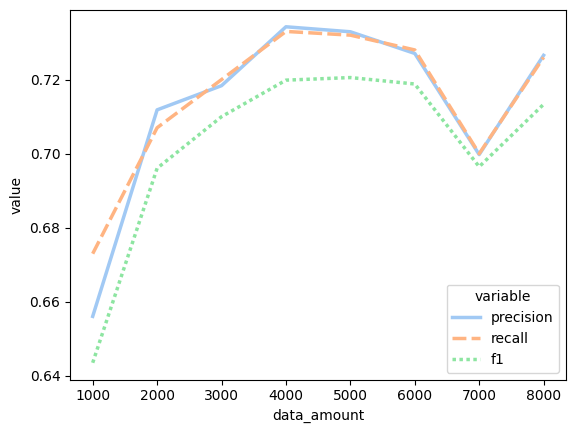

In [16]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [17]:
best_model

{'RandomForestGini': 1,
 'ExtraTreesEntr': 7,
 'CatBoost': 4,
 'LightGBMXT': 1,
 'WeightedEnsemble_L2': 6,
 'XGBoost': 1,
 'ExtraTreesGini': 3,
 'LightGBM': 1}

([<matplotlib.patches.Wedge at 0x213f0d2fed0>,
 [Text(1.0905893469510741, 0.14357881569657108, 'RandomForestGini'),
  Text(0.42095179938905597, 1.0162674759093278, 'ExtraTreesEntr'),
  Text(-0.95262792270675, 0.5500000371631103, 'CatBoost'),
  Text(-1.0905893503117785, -0.14357879016948516, 'LightGBMXT'),
  Text(-0.5500000148652441, -0.9526279355804297, 'WeightedEnsemble_L2'),
  Text(0.42095176370787, -1.0162674906889593, 'XGBoost'),
  Text(0.8726886690956921, -0.6696375787185108, 'ExtraTreesGini'),
  Text(1.0905893469510741, -0.1435788156965713, 'LightGBM')],
 [Text(0.5948669165187676, 0.07831571765267512, '4%'),
  Text(0.22961007239403047, 0.5543277141323606, '29%'),
  Text(-0.5196152305673181, 0.30000002027078737, '17%'),
  Text(-0.5948669183518791, -0.07831570372881007, '4%'),
  Text(-0.30000000810831495, -0.5196152375893253, '25%'),
  Text(0.22961005293156544, -0.5543277221939776, '4%'),
  Text(0.4760120013249229, -0.36525686111918765, '12%'),
  Text(0.5948669165187676, -0.0783157

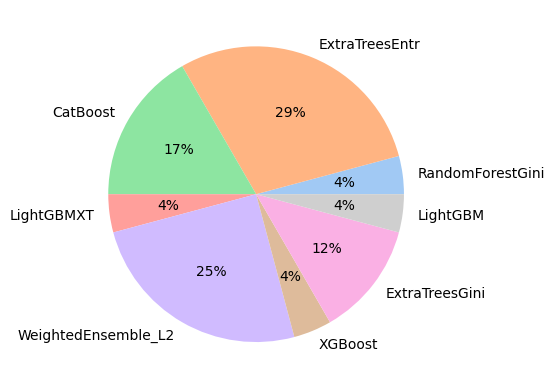

In [18]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [19]:
best_features

{'Feature 3': 8,
 'Feature 1': 6,
 'Feature 6': 2,
 'Feature 4': 1,
 'Feature 2': 5,
 'Feature 5': 2}

([<matplotlib.patches.Wedge at 0x213feaf0d50>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 3'),
  Text(-1.062518426688391, 0.2847008832926707, 'Feature 1'),
  Text(-0.7778174046868056, -0.7778175139235951, 'Feature 6'),
  Text(-0.42095169234549706, -1.016267520248218, 'Feature 4'),
  Text(0.42095184696396903, -1.0162674562031508, 'Feature 2'),
  Text(1.062518426688391, -0.2847008832926703, 'Feature 5')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.5795555054663949, 0.15529139088691127, '25%'),
  Text(-0.42426403892007575, -0.4242640985037791, '8%'),
  Text(-0.22961001400663472, -0.5543277383172097, '4%'),
  Text(0.22961009834398308, -0.5543277033835368, '21%'),
  Text(0.5795555054663949, -0.15529139088691105, '8%')])

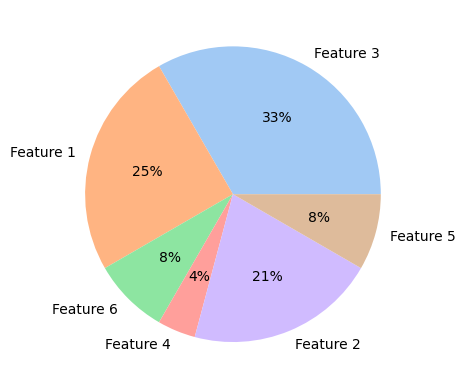

In [20]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')